# Comparing Fine-tuning without fine-tuning

In [77]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc

import os

## 35 percent participation

In [78]:
# main_folder = 'correlation_experiments_100rounds'
# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_fig5/dataseed_12346", seeds=["78", "84"],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=["5e-2", "1e-2", "1e-2"], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=[
# "gp100-35-tusu-10ft", 
# "gp100-35-tcsc-10ft", 
# "gp100-35-tcsu-10ft", 
# "gp100-12202835425057-tcsu-10ft", 
# "gp100-12202835425057-tusu-10ft", 
# "gp100-18183535355252-tcsu-10ft", 
# "gp100-18183535355252-tusu-10ft"
# ],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# raw_results_ft = load_experiment_results(config)
# raw_results_ft["availability"] = raw_results_ft["availability"].str.replace(r"-2$", "", regex=True)
# raw_results_ft['algorithm'] = "With fine-tuning"

# main_folder = 'correlation_experiments_100rounds'
# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_fig5/dataseed_12346", seeds=["78", "84"],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=["5e-2", "1e-2", "1e-2"], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=[
# "gp100-35-tusu", 
# "gp100-35-tcsc", 
# "gp100-35-tcsu", 
# "gp100-12202835425057-tcsu", 
# "gp100-12202835425057-tusu", 
# "gp100-18183535355252-tcsu", 
# "gp100-18183535355252-tusu"
# ],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

## 50 percent participation

In [79]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_fig5/dataseed_12345",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["1e-1", "5e-2", "1e-2"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=[
    "gp100-50-tusu-10ft", 
    "gp100-50-tcsc-10ft", 
    "gp100-50-tcsu-10ft", 
    "gp100-20304050607080-tcsu-10ft", 
    "gp100-20304050607080-tusu-10ft", 
    "gp100-25255050507575-tcsu-10ft", 
    "gp100-25255050507575-tusu-10ft"],
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results_ft = load_experiment_results(config)
raw_results_ft["availability"] = raw_results_ft["availability"].str.replace(r"-2$", "", regex=True)
raw_results_ft['algorithm'] = "With fine-tuning"


config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_fig5/dataseed_12345",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2", "1e-2", "1e-3"],
    alphas=["0.1"],
    n_clients_list=["7"],
    availabilities=[
    "gp100-50-tusu", 
    "gp100-50-tcsc", 
    "gp100-50-tcsu", 
    "gp100-20304050607080-tcsu", 
    "gp100-20304050607080-tusu", 
    "gp100-25255050507575-tcsu", 
    "gp100-25255050507575-tusu"],
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
    batch_sizes=["128"]
)

raw_results = load_experiment_results(config)
raw_results["availability"] = raw_results["availability"].str.replace(r"-2$", "", regex=True)
raw_results['algorithm'] = "Without fine-tuning"

Processing experiments: 100%|██████████| 3/3 [00:03<00:00,  1.11s/it]


In [80]:
import pandas as pd
final_results = pd.concat([raw_results, raw_results_ft])

In [81]:
refined_res, best_worst_res = refine_results(final_results)

folder='figures/lr_exp/quanti_analysis/ft_analysis'
keyword = 'ft_analysis'

In [82]:
from matplotlib import pyplot as plt

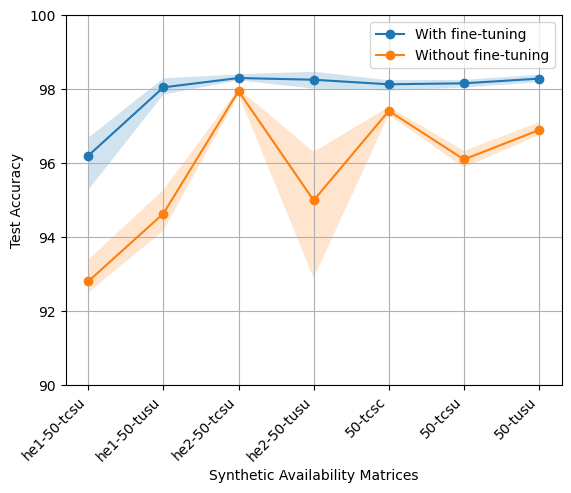

In [83]:
x_values = [a.replace('gp100-','').replace('-10ft', '').replace('12202835425057', 'he1-35').replace('18183535355252', 'he2-35').replace('20304050607080', 'he1-50').replace('25255050507575', 'he2-50') for a in best_worst_res[best_worst_res.algorithm=='With fine-tuning']['availability']]
plt.figure()
ax=plt.gca()
for algo in ['With fine-tuning', 'Without fine-tuning']:

    y = best_worst_res[best_worst_res.algorithm==algo]['best_final_mean_acc'] *100
    y_upper = best_worst_res[best_worst_res.algorithm==algo]['best_final_max_acc'] *100
    y_lower = best_worst_res[best_worst_res.algorithm==algo]['best_final_min_acc'] * 100
    plt.plot(x_values, y, '-o', label=algo)
    ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)
plt.xticks(rotation=45, ha='right')
plt.legend()
# plt.title('Final best test accuracy (mean over seeds)')
plt.grid()
ax.set_ylim([90, 100])
plt.xlabel("Synthetic Availability Matrices")
plt.ylabel("Test Accuracy")
plt.savefig(folder+'/ft_vs_noft.png', bbox_inches='tight')

## Av mat

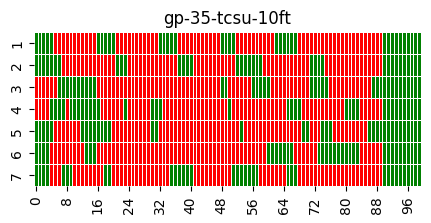

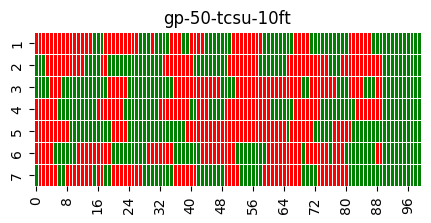

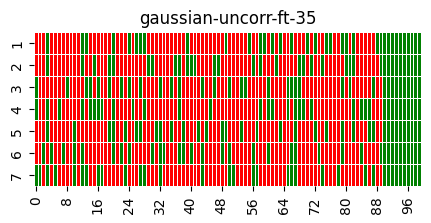

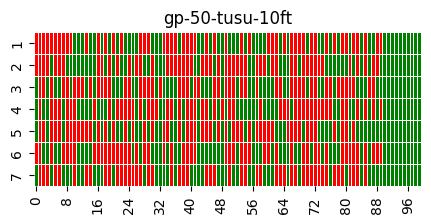

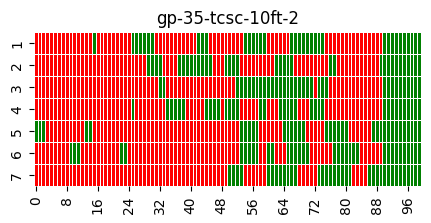

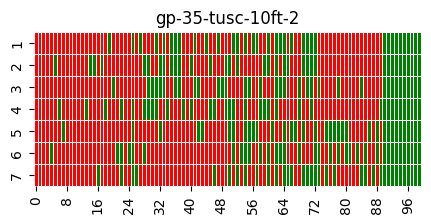

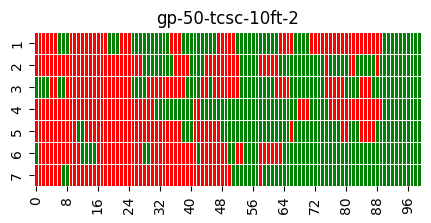

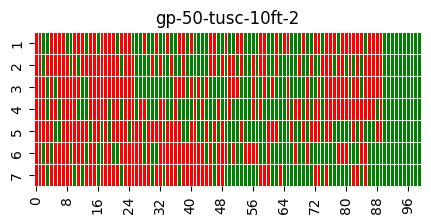

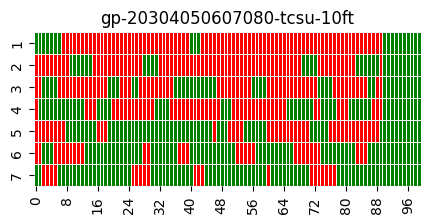

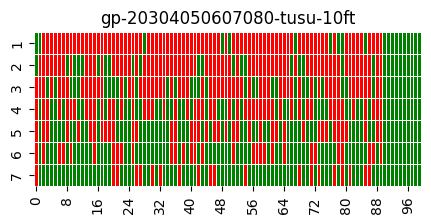

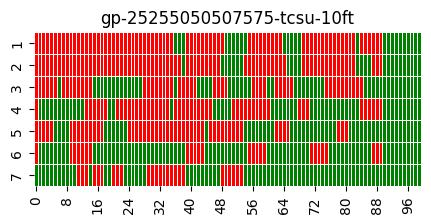

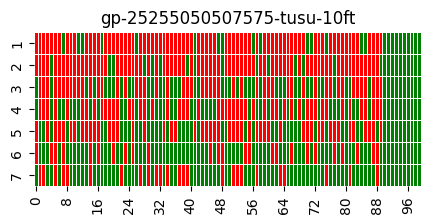

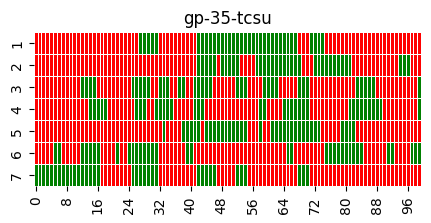

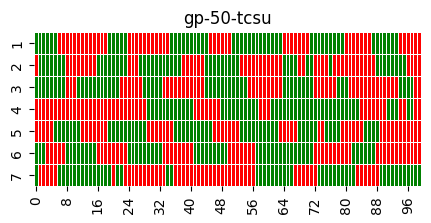

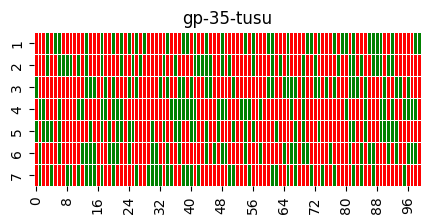

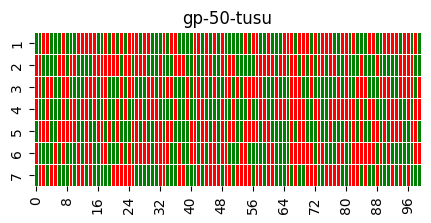

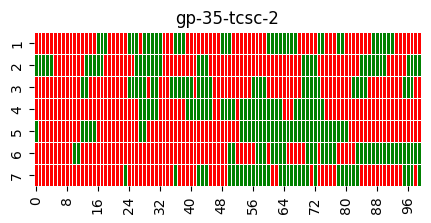

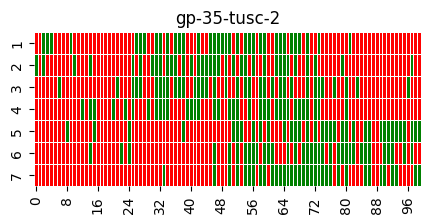

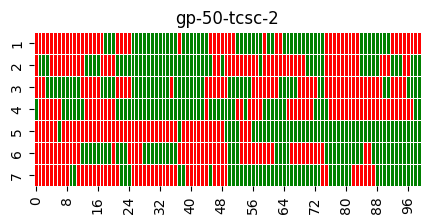

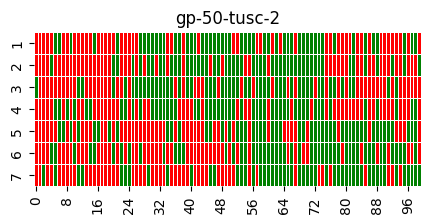

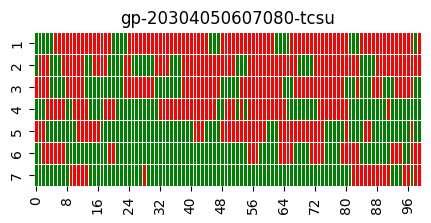

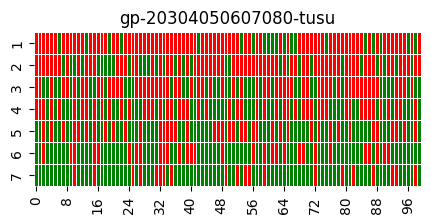

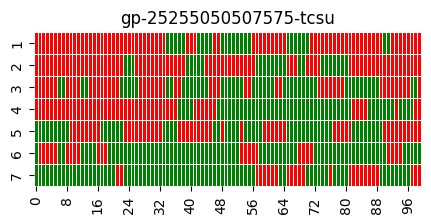

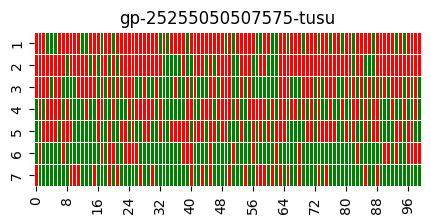

In [ ]:
av_mat_list = ['gp-35-tcsu-10ft',
 'gp-50-tcsu-10ft',
#  'gp-35-tusu-10ft',
 'gaussian-uncorr-ft-35',
 'gp-50-tusu-10ft',
 'gp-35-tcsc-10ft-2',
 'gp-35-tusc-10ft-2',
 'gp-50-tcsc-10ft-2',
 'gp-50-tusc-10ft-2',
 'gp-20304050607080-tcsu-10ft',
 'gp-20304050607080-tusu-10ft',
 'gp-25255050507575-tcsu-10ft',
 'gp-25255050507575-tusu-10ft',
 'gp-35-tcsu',
 'gp-50-tcsu',
 'gp-35-tusu',
 'gp-50-tusu',
 'gp-35-tcsc-2',
 'gp-35-tusc-2',
 'gp-50-tcsc-2',
 'gp-50-tusc-2',
 'gp-20304050607080-tcsu',
 'gp-20304050607080-tusu',
 'gp-25255050507575-tcsu',
 'gp-25255050507575-tusu']
folder='lr_exp/av_mat'
for av_mat_name in av_mat_list:
    plot_av_mat(av_mat_name, folder)